In [1]:
# ============================================================
# PHASE 23 — LEAKAGE AND BIAS AUDIT
# ============================================================
# Goal:
# Audit whether model performance may be inflated by:
# 1. duplicated genes / duplicated feature rows
# 2. train-test near-duplicate leakage
# 3. protein embedding similarity leakage
# 4. protein/genomic feature norm bias
# 5. length / GC / missingness bias if metadata is available
# 6. label separability by nuisance variables
# 7. cluster-aware split stress test
#
# This phase does not aim to improve performance.
# It aims to make the study more defensible.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, ks_2samp
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import StratifiedKFold, GroupKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 400)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE3_DIR = PROJECT_DIR / "model" / "phase3_multimodal_integration"
SHARED_DIR = PHASE3_DIR / "shared_dataset"

PHASE17_DIR = PROJECT_DIR / "model" / "phase17_repeated_cross_validation_robust_benchmark"
PHASE18_DIR = PROJECT_DIR / "model" / "phase18_negative_set_sensitivity_analysis"

PHASE23_DIR = PROJECT_DIR / "model" / "phase23_leakage_and_bias_audit"
RESULT_DIR = PHASE23_DIR / "results"
FIGURE_DIR = PHASE23_DIR / "figures"
EXCEL_DIR = PHASE23_DIR / "excel"
REPORT_DIR = PHASE23_DIR / "reports"

for d in [PHASE23_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 23 output:", PHASE23_DIR)

Mounted at /content/drive
Phase 23 output: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_npy_required(path):
    path = Path(path)
    assert path.exists(), f"Missing required file: {path}"
    arr = np.load(path, allow_pickle=True)
    print("Loaded:", path, arr.shape)
    return arr


def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=5):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def clean_gene_symbol(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s == "" or s in ["NAN", "NONE", "NULL"]:
        return None
    return s


def find_gene_column(df):
    candidates = [
        "gene_symbol", "gene", "Gene", "symbol",
        "gene_name", "hgnc_symbol", "approved_symbol"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def find_label_column(df):
    candidates = ["label", "y", "target", "class", "is_positive", "t2d_label"]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def find_sequence_column(df):
    candidates = [
        "protein_sequence", "sequence", "aa_sequence", "protein_seq",
        "Sequence", "seq", "canonical_sequence"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def row_hash_matrix(X, decimals=6):
    """
    Hash rounded feature rows to detect exact/near-exact duplicate vectors.
    """
    Xr = np.round(np.asarray(X, dtype=np.float32), decimals=decimals)
    hashes = []
    for row in Xr:
        h = hashlib.md5(row.tobytes()).hexdigest()
        hashes.append(h)
    return np.array(hashes)


def build_svm(seed=42):
    return Pipeline([
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=1.0,
            gamma="scale",
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=seed
        ))
    ])


def build_lr(seed=42):
    return Pipeline([
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=1.0,
            penalty="l2",
            solver="liblinear",
            class_weight="balanced",
            random_state=seed,
            max_iter=5000
        ))
    ])


def choose_threshold_by_mcc(y_true, y_score, n_grid=501):
    thresholds = np.unique(np.quantile(y_score, np.linspace(0, 1, n_grid)))
    best_thr = float(thresholds[0])
    best_mcc = -999

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        mcc = matthews_corrcoef(y_true, pred)
        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = float(thr)

    return best_thr, best_mcc


def get_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return model.predict(X)


def evaluate_prediction(y_true, y_score, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "threshold": float(threshold)
    }


def safe_test(pos, neg):
    pos = np.asarray(pos, dtype=float)
    neg = np.asarray(neg, dtype=float)

    pos = pos[np.isfinite(pos)]
    neg = neg[np.isfinite(neg)]

    if len(pos) < 3 or len(neg) < 3:
        return {
            "mannwhitney_p": np.nan,
            "ks_p": np.nan,
            "delta_mean_pos_minus_neg": np.nan,
            "median_pos": np.nan,
            "median_neg": np.nan
        }

    try:
        mw_p = mannwhitneyu(pos, neg, alternative="two-sided").pvalue
    except Exception:
        mw_p = np.nan

    try:
        ks_p = ks_2samp(pos, neg).pvalue
    except Exception:
        ks_p = np.nan

    return {
        "mannwhitney_p": mw_p,
        "ks_p": ks_p,
        "delta_mean_pos_minus_neg": np.mean(pos) - np.mean(neg),
        "median_pos": np.median(pos),
        "median_neg": np.median(neg)
    }

In [3]:
# ============================================================
# LOAD FEATURES AND LABELS
# ============================================================

SHARED_DIR = PHASE3_DIR / "features"
PHASE5_DIR1 = PROJECT_DIR / "model" / "phase5_dnabert2_genomic_foundation"
SHARED_DIR1 = PHASE5_DIR1 / "embeddings"
SHARED_DIR2 = PHASE3_DIR / "shared_dataset"

# Protein
X_train_protein = load_npy_required(SHARED_DIR / "X_train_protein_protbert_sw_v1.npy")
X_val_protein   = load_npy_required(SHARED_DIR / "X_val_protein_protbert_sw_v1.npy")
X_test_protein  = load_npy_required(SHARED_DIR / "X_test_protein_protbert_sw_v1.npy")

# Handcrafted multimodal: ProtBERT + K3/K4/Basic
X_train_hand = load_npy_required(SHARED_DIR / "X_train_combined_protein_genomic_v1.npy")
X_val_hand   = load_npy_required(SHARED_DIR / "X_val_combined_protein_genomic_v1.npy")
X_test_hand  = load_npy_required(SHARED_DIR / "X_test_combined_protein_genomic_v1.npy")

# DNABERT-2 multimodal: ProtBERT + DNABERT-2
X_train_dna = load_npy_required(SHARED_DIR1 / "X_train_combined_protbert_sw_dnabert2_v1.npy")
X_val_dna   = load_npy_required(SHARED_DIR1 / "X_val_combined_protbert_sw_dnabert2_v1.npy")
X_test_dna  = load_npy_required(SHARED_DIR1 / "X_test_combined_protbert_sw_dnabert2_v1.npy")

# Labels
y_train = load_npy_required(SHARED_DIR2 / "y_train_multimodal_v1.npy").astype(int)
y_val   = load_npy_required(SHARED_DIR2 / "y_val_multimodal_v1.npy").astype(int)
y_test  = load_npy_required(SHARED_DIR2 / "y_test_multimodal_v1.npy").astype(int)

# Combine old train + val + test into one full shared dataset
X_protein_full = np.vstack([X_train_protein, X_val_protein, X_test_protein])
X_hand_full = np.vstack([X_train_hand, X_val_hand, X_test_hand])
X_dna_full = np.vstack([X_train_dna, X_val_dna, X_test_dna])
y_full = np.concatenate([y_train, y_val, y_test]).astype(int)

PROTEIN_DIM = 1024
X_genomic_hand_full = X_hand_full[:, PROTEIN_DIM:]
X_genomic_dna_full = X_dna_full[:, PROTEIN_DIM:]

split_origin = (
    ["train"] * len(y_train) +
    ["val"] * len(y_val) +
    ["test"] * len(y_test)
)

print("Full shapes:")
print("Protein:", X_protein_full.shape)
print("Handcrafted genomic:", X_genomic_hand_full.shape)
print("DNABERT2 genomic:", X_genomic_dna_full.shape)
print("Handcrafted multimodal:", X_hand_full.shape)
print("DNABERT2 multimodal:", X_dna_full.shape)
print("Labels:", y_full.shape, np.bincount(y_full))

Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_protein_protbert_sw_v1.npy (1264, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_protein_protbert_sw_v1.npy (271, 1024)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_train_combined_protein_genomic_v1.npy (1264, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_combined_protein_genomic_v1.npy (271, 1380)
Loaded: /content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_combined_protbert_sw_dnabert2_v1.npy (1264, 1792

In [4]:
# ============================================================
# LOAD OR RECONSTRUCT SAMPLE METADATA
# ============================================================

metadata_candidates = []

preferred_paths = [
    PHASE18_DIR / "results" / "phase18_sample_metadata_used.csv",
    PHASE17_DIR / "results" / "phase17_repeated_cv_all_predictions.csv",
]

for p in preferred_paths:
    if p.exists():
        try:
            df = pd.read_csv(p)
            metadata_candidates.append((p, df.shape, df.columns.tolist()[:20]))
        except Exception:
            pass

# Broad search for dataset metadata with correct length
for pattern in ["*metadata*.csv", "*sample*.csv", "*split*.csv", "*dataset*.csv", "*gene*.csv", "*multimodal*.csv"]:
    for p in PROJECT_DIR.rglob(pattern):
        try:
            if p.stat().st_size > 100 * 1024 * 1024:
                continue
            df = pd.read_csv(p)
            if len(df) in [len(y_full), len(y_train), len(y_val), len(y_test)]:
                metadata_candidates.append((p, df.shape, df.columns.tolist()[:20]))
        except Exception:
            pass

metadata_candidates_df = pd.DataFrame([
    {
        "path": str(p),
        "shape": str(shape),
        "columns_preview": "; ".join(map(str, cols))
    }
    for p, shape, cols in metadata_candidates
]).drop_duplicates()

display(metadata_candidates_df.head(50))
save_df(metadata_candidates_df, RESULT_DIR / "phase23_metadata_candidates.csv")

sample_metadata_df = None

# Prefer Phase18 full metadata
phase18_meta = PHASE18_DIR / "results" / "phase18_sample_metadata_used.csv"
if phase18_meta.exists():
    tmp = pd.read_csv(phase18_meta)
    if len(tmp) == len(y_full):
        sample_metadata_df = tmp.copy()
        print("Using metadata:", phase18_meta)

# Otherwise choose first full-length metadata
if sample_metadata_df is None:
    for p, shape, cols in metadata_candidates:
        try:
            tmp = pd.read_csv(p)
            if len(tmp) == len(y_full):
                sample_metadata_df = tmp.copy()
                print("Using metadata candidate:", p)
                break
        except Exception:
            pass

if sample_metadata_df is None:
    sample_metadata_df = pd.DataFrame({
        "sample_index": np.arange(len(y_full)),
        "gene_symbol": [f"SAMPLE_{i}" for i in range(len(y_full))],
        "label": y_full
    })
    print("No full metadata found. Created generic metadata.")

sample_metadata_df = sample_metadata_df.reset_index(drop=True)

if "sample_index" not in sample_metadata_df.columns:
    sample_metadata_df["sample_index"] = np.arange(len(sample_metadata_df))

gene_col = find_gene_column(sample_metadata_df)
if gene_col is None:
    sample_metadata_df["gene_symbol"] = [f"SAMPLE_{i}" for i in range(len(sample_metadata_df))]
else:
    sample_metadata_df["gene_symbol"] = sample_metadata_df[gene_col].apply(clean_gene_symbol)

label_col = find_label_column(sample_metadata_df)
if label_col is None:
    sample_metadata_df["label"] = y_full
else:
    sample_metadata_df["label"] = sample_metadata_df[label_col].astype(int)

sample_metadata_df["label_from_array"] = y_full
sample_metadata_df["label_match"] = sample_metadata_df["label"].astype(int) == y_full
sample_metadata_df["split_origin"] = split_origin

display(sample_metadata_df.head())
display(sample_metadata_df["label_match"].value_counts())

save_df(sample_metadata_df, RESULT_DIR / "phase23_sample_metadata_used.csv")

,path,shape,columns_preview
0,/content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_sample_metadata_used.csv,"(1806, 14)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol; sample_index; label_from_array
1,/content/drive/MyDrive/Project_Protein/model/phase17_repeated_cross_validation_robust_benchmark/results/phase17_repeated_cv_all_predictions.csv,"(36120, 7)",split_id; model_name; sample_index; true_label; score; threshold; pred_label
2,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/train_genomic_metadata_v1.csv,"(1264, 3)",gene_id; gene_symbol; label
3,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/val_genomic_metadata_v1.csv,"(271, 3)",gene_id; gene_symbol; label
4,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/test_genomic_metadata_v1.csv,"(271, 3)",gene_id; gene_symbol; label
5,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/train_multimodal_metadata_v1.csv,"(1264, 12)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol
6,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/val_multimodal_metadata_v1.csv,"(271, 12)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol
7,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/test_multimodal_metadata_v1.csv,"(271, 12)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol
8,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/shared_dataset/all_shared_multimodal_metadata_v1.csv,"(1806, 12)",gene_id; gene_symbol_protein; label_protein; protein_row_index; original_protein_split; gene_symbol_genomic; label_genomic; genomic_row_index; original_genomic_split; label_match; label; gene_symbol
9,/content/drive/MyDrive/Project_Protein/model/phase5_dnabert2_genomic_foundation/embeddings/X_train_dnabert2_sw2048_stride1024_partial_metadata.csv,"(1264, 7)",split; row_idx; gene_id; gene_symbol; label; sequence_length; n_windows


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_metadata_candidates.csv
Using metadata: /content/drive/MyDrive/Project_Protein/model/phase18_negative_set_sensitivity_analysis/results/phase18_sample_metadata_used.csv


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,sample_index,label_from_array,split_origin
0,ENSG00000205155,PSENEN,0,0,train,PSENEN,0,1589,test,True,0,PSENEN,0,0,train
1,ENSG00000164530,PI16,1,1,train,PI16,1,250,train,True,1,PI16,1,1,train
2,ENSG00000143167,GPA33,0,2,train,GPA33,0,1634,test,True,0,GPA33,2,0,train
3,ENSG00000137691,CFAP300,0,3,train,CFAP300,0,511,train,True,0,CFAP300,3,0,train
4,ENSG00000095981,KCNK16,1,4,train,KCNK16,1,837,train,True,1,KCNK16,4,1,train


,count
label_match,
True,942
False,864


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_sample_metadata_used.csv


In [5]:
# ============================================================
# DUPLICATE GENE AND DUPLICATE FEATURE AUDIT
# ============================================================

duplicate_records = []

# Gene symbol duplicates
if "gene_symbol" in sample_metadata_df.columns:
    gene_counts = sample_metadata_df["gene_symbol"].value_counts(dropna=False)
    duplicated_genes = gene_counts[gene_counts > 1]

    duplicate_records.append({
        "audit_type": "duplicate_gene_symbol",
        "n_unique_items": int(gene_counts.shape[0]),
        "n_duplicated_items": int(duplicated_genes.shape[0]),
        "n_rows_in_duplicated_items": int(gene_counts[gene_counts > 1].sum()),
        "notes": "Duplicate gene symbols across the full candidate table."
    })

    duplicate_gene_df = (
        sample_metadata_df[sample_metadata_df["gene_symbol"].isin(duplicated_genes.index)]
        .sort_values("gene_symbol")
        .copy()
    )
else:
    duplicate_gene_df = pd.DataFrame()

# Feature row duplicates
feature_matrices = {
    "Protein_ProtBERT": X_protein_full,
    "Handcrafted_genomic": X_genomic_hand_full,
    "DNABERT2_genomic": X_genomic_dna_full,
    "Handcrafted_multimodal": X_hand_full,
    "DNABERT2_multimodal": X_dna_full
}

feature_duplicate_tables = {}

for name, X in feature_matrices.items():
    hashes = row_hash_matrix(X, decimals=6)
    hash_counts = pd.Series(hashes).value_counts()
    duplicated_hashes = hash_counts[hash_counts > 1]

    duplicate_records.append({
        "audit_type": f"duplicate_feature_rows_{name}",
        "n_unique_items": int(hash_counts.shape[0]),
        "n_duplicated_items": int(duplicated_hashes.shape[0]),
        "n_rows_in_duplicated_items": int(hash_counts[hash_counts > 1].sum()),
        "notes": "Rounded feature vectors hashed at 6 decimals."
    })

    tmp = pd.DataFrame({
        "sample_index": np.arange(len(y_full)),
        "gene_symbol": sample_metadata_df["gene_symbol"].values,
        "label": y_full,
        "split_origin": split_origin,
        "feature_hash": hashes
    })

    feature_duplicate_tables[name] = tmp[tmp["feature_hash"].isin(duplicated_hashes.index)].copy()

duplicate_summary_df = pd.DataFrame(duplicate_records)

display(duplicate_summary_df)
display(duplicate_gene_df.head(50))

save_df(duplicate_summary_df, RESULT_DIR / "phase23_duplicate_audit_summary.csv")
save_df(duplicate_gene_df, RESULT_DIR / "phase23_duplicate_gene_symbols.csv")

for name, df in feature_duplicate_tables.items():
    save_df(df, RESULT_DIR / f"phase23_duplicate_feature_rows_{name}.csv")

,audit_type,n_unique_items,n_duplicated_items,n_rows_in_duplicated_items,notes
0,duplicate_gene_symbol,1806,0,0,Duplicate gene symbols across the full candidate table.
1,duplicate_feature_rows_Protein_ProtBERT,1806,0,0,Rounded feature vectors hashed at 6 decimals.
2,duplicate_feature_rows_Handcrafted_genomic,1805,1,2,Rounded feature vectors hashed at 6 decimals.
3,duplicate_feature_rows_DNABERT2_genomic,1805,1,2,Rounded feature vectors hashed at 6 decimals.
4,duplicate_feature_rows_Handcrafted_multimodal,1806,0,0,Rounded feature vectors hashed at 6 decimals.
5,duplicate_feature_rows_DNABERT2_multimodal,1806,0,0,Rounded feature vectors hashed at 6 decimals.


,gene_id,gene_symbol_protein,label_protein,protein_row_index,original_protein_split,gene_symbol_genomic,label_genomic,genomic_row_index,original_genomic_split,label_match,label,gene_symbol,sample_index,label_from_array,split_origin


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_audit_summary.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_gene_symbols.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_feature_rows_Protein_ProtBERT.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_feature_rows_Handcrafted_genomic.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_feature_rows_DNABERT2_genomic.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_feature_rows_Handcrafted_multimodal.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_feature_rows_DNABERT2_multimodal.csv


In [6]:
# ============================================================
# ORIGINAL SPLIT TRAIN-TEST NEAR-NEIGHBOR LEAKAGE AUDIT
# ============================================================
# Checks whether test samples have near-identical protein embeddings
# to train/validation samples.
# ============================================================

scaler = StandardScaler()
X_protein_scaled = scaler.fit_transform(X_protein_full)

idx_train = np.where(np.array(split_origin) == "train")[0]
idx_val = np.where(np.array(split_origin) == "val")[0]
idx_test = np.where(np.array(split_origin) == "test")[0]

idx_trainval = np.concatenate([idx_train, idx_val])

X_ref = X_protein_scaled[idx_trainval]
X_query = X_protein_scaled[idx_test]

# Cosine similarity can be memory-heavy but is fine for ~1,806 samples
sim = cosine_similarity(X_query, X_ref)

nearest_ref_pos = np.argmax(sim, axis=1)
nearest_sim = np.max(sim, axis=1)
nearest_ref_idx = idx_trainval[nearest_ref_pos]

nn_leakage_df = pd.DataFrame({
    "test_sample_index": idx_test,
    "test_gene_symbol": sample_metadata_df.loc[idx_test, "gene_symbol"].values,
    "test_label": y_full[idx_test],
    "nearest_trainval_sample_index": nearest_ref_idx,
    "nearest_trainval_gene_symbol": sample_metadata_df.loc[nearest_ref_idx, "gene_symbol"].values,
    "nearest_trainval_label": y_full[nearest_ref_idx],
    "nearest_trainval_split": np.array(split_origin)[nearest_ref_idx],
    "max_cosine_similarity_to_trainval": nearest_sim
})

# Risk categories
def sim_risk(s):
    if s >= 0.999:
        return "very_high_possible_duplicate"
    if s >= 0.99:
        return "high_near_duplicate"
    if s >= 0.95:
        return "moderate_high_similarity"
    return "lower_similarity"

nn_leakage_df["similarity_risk"] = nn_leakage_df["max_cosine_similarity_to_trainval"].apply(sim_risk)

nn_summary_df = (
    nn_leakage_df
    .groupby("similarity_risk", as_index=False)
    .agg(
        n_test_samples=("test_sample_index", "count"),
        mean_similarity=("max_cosine_similarity_to_trainval", "mean"),
        max_similarity=("max_cosine_similarity_to_trainval", "max")
    )
)

nn_summary_df = round_numeric_columns(nn_summary_df, 6)

display(nn_summary_df)
display(nn_leakage_df.sort_values("max_cosine_similarity_to_trainval", ascending=False).head(30))

save_df(nn_leakage_df, RESULT_DIR / "phase23_original_split_nearest_neighbor_leakage_audit.csv")
save_df(nn_summary_df, RESULT_DIR / "phase23_original_split_nearest_neighbor_summary.csv")

,similarity_risk,n_test_samples,mean_similarity,max_similarity
0,high_near_duplicate,1,0.994958,0.994958
1,lower_similarity,267,0.701561,0.946954
2,moderate_high_similarity,3,0.959204,0.971805


,test_sample_index,test_gene_symbol,test_label,nearest_trainval_sample_index,nearest_trainval_gene_symbol,nearest_trainval_label,nearest_trainval_split,max_cosine_similarity_to_trainval,similarity_risk
162,1697,CEP104,0,1288,SUGP2,0,val,0.994958,high_near_duplicate
124,1659,ARL15,1,587,PCNT,1,train,0.971805,moderate_high_similarity
109,1644,COLGALT1,1,560,VDR,1,train,0.955717,moderate_high_similarity
45,1580,KLHL42,0,471,MYO19,0,train,0.950091,moderate_high_similarity
257,1792,HHIPL1,1,612,SMARCAD1,0,train,0.946954,lower_similarity
21,1556,C10ORF71,0,1186,RHOG,0,train,0.936292,lower_similarity
196,1731,FFAR1,1,426,TECPR1,0,train,0.934097,lower_similarity
221,1756,SLC5A1,1,1133,HK1,0,train,0.932329,lower_similarity
89,1624,NDUFB3,0,770,CFAP47,1,train,0.921736,lower_similarity
267,1802,PIM3,1,423,IGSF10,1,train,0.921599,lower_similarity


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_original_split_nearest_neighbor_leakage_audit.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_original_split_nearest_neighbor_summary.csv


In [7]:
# ============================================================
# NUISANCE FEATURE CONSTRUCTION AND BIAS TESTS
# ============================================================

bias_df = sample_metadata_df[["sample_index", "gene_symbol", "label", "split_origin"]].copy()

# Feature norms and simple summaries
bias_df["protein_embedding_l2_norm"] = np.linalg.norm(X_protein_full, axis=1)
bias_df["protein_embedding_mean"] = X_protein_full.mean(axis=1)
bias_df["protein_embedding_std"] = X_protein_full.std(axis=1)

bias_df["hand_genomic_l2_norm"] = np.linalg.norm(X_genomic_hand_full, axis=1)
bias_df["hand_genomic_mean"] = X_genomic_hand_full.mean(axis=1)
bias_df["hand_genomic_std"] = X_genomic_hand_full.std(axis=1)

bias_df["dnabert2_genomic_l2_norm"] = np.linalg.norm(X_genomic_dna_full, axis=1)
bias_df["dnabert2_genomic_mean"] = X_genomic_dna_full.mean(axis=1)
bias_df["dnabert2_genomic_std"] = X_genomic_dna_full.std(axis=1)

# Missingness / zero vector proxies
bias_df["protein_zero_fraction"] = np.mean(np.isclose(X_protein_full, 0), axis=1)
bias_df["hand_genomic_zero_fraction"] = np.mean(np.isclose(X_genomic_hand_full, 0), axis=1)
bias_df["dnabert2_genomic_zero_fraction"] = np.mean(np.isclose(X_genomic_dna_full, 0), axis=1)

# Sequence length if sequence column exists
seq_col = find_sequence_column(sample_metadata_df)

if seq_col is not None:
    bias_df["protein_sequence_length"] = sample_metadata_df[seq_col].astype(str).str.len()
    bias_df["has_sequence"] = sample_metadata_df[seq_col].notna().astype(int)
else:
    bias_df["protein_sequence_length"] = np.nan
    bias_df["has_sequence"] = np.nan

# Gene symbol string proxy, not biological but useful to detect metadata artifacts
bias_df["gene_symbol_length"] = bias_df["gene_symbol"].astype(str).str.len()

numeric_bias_cols = [
    "protein_embedding_l2_norm",
    "protein_embedding_mean",
    "protein_embedding_std",
    "hand_genomic_l2_norm",
    "hand_genomic_mean",
    "hand_genomic_std",
    "dnabert2_genomic_l2_norm",
    "dnabert2_genomic_mean",
    "dnabert2_genomic_std",
    "protein_zero_fraction",
    "hand_genomic_zero_fraction",
    "dnabert2_genomic_zero_fraction",
    "protein_sequence_length",
    "gene_symbol_length"
]

bias_test_records = []

for col in numeric_bias_cols:
    pos = bias_df.loc[bias_df["label"] == 1, col].values
    neg = bias_df.loc[bias_df["label"] == 0, col].values

    res = safe_test(pos, neg)
    res.update({
        "feature": col,
        "n_pos_nonmissing": int(np.isfinite(pos).sum()),
        "n_neg_nonmissing": int(np.isfinite(neg).sum())
    })
    bias_test_records.append(res)

bias_test_df = pd.DataFrame(bias_test_records)

# FDR correction
for p_col in ["mannwhitney_p", "ks_p"]:
    valid = bias_test_df[p_col].notna()
    bias_test_df[f"{p_col}_bh_fdr"] = np.nan
    if valid.sum() > 0:
        bias_test_df.loc[valid, f"{p_col}_bh_fdr"] = multipletests(
            bias_test_df.loc[valid, p_col],
            method="fdr_bh"
        )[1]

bias_test_df = bias_test_df[
    [
        "feature",
        "n_pos_nonmissing",
        "n_neg_nonmissing",
        "median_pos",
        "median_neg",
        "delta_mean_pos_minus_neg",
        "mannwhitney_p",
        "mannwhitney_p_bh_fdr",
        "ks_p",
        "ks_p_bh_fdr"
    ]
]

bias_test_df = round_numeric_columns(bias_test_df, 6)

display(bias_test_df)

save_df(bias_df, RESULT_DIR / "phase23_nuisance_feature_table.csv")
save_df(bias_test_df, RESULT_DIR / "phase23_pos_neg_nuisance_bias_tests.csv")

,feature,n_pos_nonmissing,n_neg_nonmissing,median_pos,median_neg,delta_mean_pos_minus_neg,mannwhitney_p,mannwhitney_p_bh_fdr,ks_p,ks_p_bh_fdr
0,protein_embedding_l2_norm,903,903,3.457318,3.459795,0.034377,0.524922,0.758220,0.814626,1.000000
1,protein_embedding_mean,903,903,0.001392,0.001401,-0.000009,0.659585,0.766003,0.173161,0.750363
2,protein_embedding_std,903,903,0.108030,0.108104,0.001075,0.524745,0.758220,0.814626,1.000000
3,hand_genomic_l2_norm,903,903,3319.875562,3319.103217,1.387491,0.457489,0.758220,0.778449,1.000000
4,hand_genomic_mean,903,903,21.805439,21.812736,-0.003539,0.707080,0.766003,0.814626,1.000000
5,hand_genomic_std,903,903,174.587900,174.567557,0.074509,0.456069,0.758220,0.622408,1.000000
6,dnabert2_genomic_l2_norm,903,903,2.568856,2.562109,0.009617,0.218007,0.711704,0.506520,1.000000
7,dnabert2_genomic_mean,903,903,0.002705,0.002691,-0.000009,0.662463,0.766003,0.931581,1.000000
8,dnabert2_genomic_std,903,903,0.092659,0.092412,0.000347,0.218986,0.711704,0.506520,1.000000
9,protein_zero_fraction,903,903,0.000000,0.000000,-0.000001,0.317847,0.758220,1.000000,1.000000


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_nuisance_feature_table.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_pos_neg_nuisance_bias_tests.csv


In [8]:
# ============================================================
# NUISANCE-ONLY PREDICTIVE AUDIT
# ============================================================
# Question:
# Can simple nuisance variables alone predict labels?
# If yes, performance may partially reflect confounding.
# ============================================================

nuisance_cols = [
    "protein_embedding_l2_norm",
    "protein_embedding_mean",
    "protein_embedding_std",
    "hand_genomic_l2_norm",
    "hand_genomic_mean",
    "hand_genomic_std",
    "dnabert2_genomic_l2_norm",
    "dnabert2_genomic_mean",
    "dnabert2_genomic_std",
    "protein_zero_fraction",
    "hand_genomic_zero_fraction",
    "dnabert2_genomic_zero_fraction",
    "gene_symbol_length"
]

if bias_df["protein_sequence_length"].notna().sum() > 0:
    nuisance_cols.append("protein_sequence_length")

X_nuisance = bias_df[nuisance_cols].copy()
X_nuisance = X_nuisance.replace([np.inf, -np.inf], np.nan)
X_nuisance = X_nuisance.fillna(X_nuisance.median(numeric_only=True))

y = y_full

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_SEED
)

nuisance_records = []

for split_id, (train_idx, test_idx) in enumerate(cv.split(X_nuisance, y), start=1):
    # inner validation from train
    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED + split_id)
    inner_train_rel, val_rel = next(inner.split(X_nuisance.iloc[train_idx], y[train_idx]))

    inner_train_idx = train_idx[inner_train_rel]
    val_idx = train_idx[val_rel]

    model = build_lr(seed=RANDOM_SEED + split_id)
    model.fit(X_nuisance.iloc[inner_train_idx], y[inner_train_idx])

    val_score = get_scores(model, X_nuisance.iloc[val_idx])
    threshold, val_mcc = choose_threshold_by_mcc(y[val_idx], val_score)

    test_score = get_scores(model, X_nuisance.iloc[test_idx])
    metrics = evaluate_prediction(y[test_idx], test_score, threshold)

    nuisance_records.append({
        "split_id": split_id,
        "model_name": "Nuisance_only_LogisticRegression",
        "n_features": len(nuisance_cols),
        "features": "; ".join(nuisance_cols),
        "validation_mcc": val_mcc,
        **metrics
    })

nuisance_cv_df = pd.DataFrame(nuisance_records)
nuisance_cv_df = round_numeric_columns(nuisance_cv_df, 5)

nuisance_summary_df = (
    nuisance_cv_df
    .agg({
        "roc_auc": ["mean", "std"],
        "pr_auc": ["mean", "std"],
        "mcc": ["mean", "std"],
        "f1": ["mean", "std"]
    })
    .T
    .reset_index()
    .rename(columns={"index": "metric", "mean": "mean", "std": "sd"})
)

nuisance_summary_df = round_numeric_columns(nuisance_summary_df, 5)

display(nuisance_cv_df.head())
display(nuisance_summary_df)

save_df(nuisance_cv_df, RESULT_DIR / "phase23_nuisance_only_cv_metrics.csv")
save_df(nuisance_summary_df, RESULT_DIR / "phase23_nuisance_only_cv_summary.csv")

,split_id,model_name,n_features,features,validation_mcc,roc_auc,pr_auc,accuracy,precision,recall,specificity,f1,mcc,tn,fp,fn,tp,threshold
0,1,Nuisance_only_LogisticRegression,13,protein_embedding_l2_norm; protein_embedding_mean; protein_embedding_std; hand_genomic_l2_norm; hand_genomic_mean; hand_genomic_std; dnabert2_genomic_l2_norm; dnabert2_genomic_mean; dnabert2_genomic_std; protein_zero_fraction; hand_genomic_zero_fraction; dnabert2_genomic_zero_fraction; gene_symbol_length,0.16108,0.64833,0.66055,0.51934,0.51020,0.96685,0.07182,0.66794,0.08671,13,168,6,175,0.25110
1,2,Nuisance_only_LogisticRegression,13,protein_embedding_l2_norm; protein_embedding_mean; protein_embedding_std; hand_genomic_l2_norm; hand_genomic_mean; hand_genomic_std; dnabert2_genomic_l2_norm; dnabert2_genomic_mean; dnabert2_genomic_std; protein_zero_fraction; hand_genomic_zero_fraction; dnabert2_genomic_zero_fraction; gene_symbol_length,0.22183,0.60998,0.60056,0.54017,0.63462,0.18333,0.89503,0.28448,0.11158,162,19,147,33,0.63512
2,3,Nuisance_only_LogisticRegression,13,protein_embedding_l2_norm; protein_embedding_mean; protein_embedding_std; hand_genomic_l2_norm; hand_genomic_mean; hand_genomic_std; dnabert2_genomic_l2_norm; dnabert2_genomic_mean; dnabert2_genomic_std; protein_zero_fraction; hand_genomic_zero_fraction; dnabert2_genomic_zero_fraction; gene_symbol_length,0.19612,0.63066,0.63036,0.59280,0.58639,0.62222,0.56354,0.60377,0.18607,102,79,68,112,0.49795
3,4,Nuisance_only_LogisticRegression,13,protein_embedding_l2_norm; protein_embedding_mean; protein_embedding_std; hand_genomic_l2_norm; hand_genomic_mean; hand_genomic_std; dnabert2_genomic_l2_norm; dnabert2_genomic_mean; dnabert2_genomic_std; protein_zero_fraction; hand_genomic_zero_fraction; dnabert2_genomic_zero_fraction; gene_symbol_length,0.27002,0.68505,0.64547,0.60942,0.57519,0.84530,0.37222,0.68456,0.24699,67,113,28,153,0.43167
4,5,Nuisance_only_LogisticRegression,13,protein_embedding_l2_norm; protein_embedding_mean; protein_embedding_std; hand_genomic_l2_norm; hand_genomic_mean; hand_genomic_std; dnabert2_genomic_l2_norm; dnabert2_genomic_mean; dnabert2_genomic_std; protein_zero_fraction; hand_genomic_zero_fraction; dnabert2_genomic_zero_fraction; gene_symbol_length,0.30922,0.59500,0.60556,0.52632,0.52551,0.56906,0.48333,0.54642,0.05259,87,93,78,103,0.50956


,metric,mean,sd
0,roc_auc,0.63318,0.02407
1,pr_auc,0.62675,0.02095
2,mcc,0.16428,0.05124
3,f1,0.54146,0.11987


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_nuisance_only_cv_metrics.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_nuisance_only_cv_summary.csv


In [9]:
# ============================================================
# EMBEDDING CLUSTER CONSTRUCTION FOR GROUP-AWARE SPLIT
# ============================================================
# This is a surrogate for homology-aware split.
# It clusters protein embeddings and prevents samples from the same
# cluster from appearing in both train and test.
#
# This does not replace CD-HIT/MMseqs2, but it is useful as an audit.
# ============================================================

N_CLUSTERS = 120

# PCA before KMeans for stability/speed
pca = PCA(n_components=min(50, X_protein_full.shape[1]), random_state=RANDOM_SEED)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_protein_full))

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_SEED,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_pca)

cluster_df = sample_metadata_df[["sample_index", "gene_symbol", "label", "split_origin"]].copy()
cluster_df["protein_embedding_cluster"] = cluster_labels

cluster_summary_df = (
    cluster_df
    .groupby("protein_embedding_cluster", as_index=False)
    .agg(
        n_samples=("sample_index", "count"),
        n_positive=("label", "sum"),
        n_negative=("label", lambda x: int(np.sum(np.asarray(x) == 0))),
        genes=("gene_symbol", lambda x: "; ".join(map(str, list(x)[:20])))
    )
)

cluster_summary_df["positive_rate"] = cluster_summary_df["n_positive"] / cluster_summary_df["n_samples"]

cluster_summary_df = round_numeric_columns(cluster_summary_df, 4)

display(cluster_summary_df.sort_values("n_samples", ascending=False).head(20))

save_df(cluster_df, RESULT_DIR / "phase23_protein_embedding_clusters.csv")
save_df(cluster_summary_df, RESULT_DIR / "phase23_protein_embedding_cluster_summary.csv")

,protein_embedding_cluster,n_samples,n_positive,n_negative,genes,positive_rate
12,12,50,17,33,CFAP300; ADAMTS18; PCSK5; CDC123; DNAI2; ZFYVE21; MFSD6L; SBF1; XRN2; RBM23; PLCL2; INSR; LTBP3; RSAD1; TSPAN8; SAG; FST; CA10; ITIH6; IFNW1,0.3400
5,5,42,20,22,SNX2; EMSY; WFS1; CDC42BPB; DCLK2; OR6M1; CCDC8; ADRA1B; TPK1; CCSER1; KCNIP4; TNKS1BP1; SRP54; FUT9; KCNK4; FOXN3; ATAD2; NTNG1; ABCA6; LAMC1,0.4762
33,33,40,23,17,TPRA1; IL12B; EYA1; ARMC8; PBX4; GRIN2D; DNASE1; KIF26A; GRAMD2B; TCP11X1; SIPA1; EIF2AK1; ZSWIM9; ZNF814; CTSH; TMEM17; KBTBD3; NMI; ATP2A3; HNF1A,0.5750
18,18,36,12,24,OSGIN2; KCNG4; PROSER2; C11ORF24; FAM221B; PDE3B; ZNF324B; NUDT4B; LAMA3; NDUFAB1; RAB42; PCYOX1; NYNRIN; ZNF343; NDUFB10; DENND2A; DROSHA; NFX1; RPA4; PLCZ1,0.3333
16,16,35,17,18,EXOSC10; ASAH1; LRRK1; CST11; TSPEAR; MLXIPL; RBPJ; PDGFC; FSCN3; ARID3B; CCDC110; ZMIZ1; SI; ZNF664; TET2; RLF; SEC14L3; ALDH16A1; SLC45A4; C2CD4D,0.4857
76,76,32,23,9,WIPI1; SHLD2; ADRA1D; TENT5A; PAXIP1; SEPTIN3; FAM90A26; CAMK2B; IL13; FITM2; PLPPR1; ZNF281; DHTKD1; SIGLEC9; CDC25A; LRRC74A; C12ORF43; ZNF532; BMF; PACRG,0.7188
114,114,29,17,12,LEP; FOXRED2; ZFP92; HMHB1; BAHCC1; PCDHGB5; FABP9; CEP350; DRD2; BTBD1; ZNF717; GPR26; NDUFS5; PAGE3; TBC1D8; HNF1B; ANKDD1B; EPB41L4A; PELO; KRTAP20-1,0.5862
42,42,29,18,11,TM6SF2; CNTN2; SPTBN4; DDX28; DYNLT3; WSCD2; ZFAND3; QSER1; L3MBTL3; CCDC81; LRP12; KLHL21; EXOC1; IL13RA1; TOMM7; PLCB4; FAM184A; PGM1; CIC; BACH2,0.6207
61,61,27,12,15,GAL3ST4; ATXN7L3; ST6GAL1; ZNF416; MYBL2; SMAD3; IGSF10; JMJD1C; OTOGL; DUSP23; PPP4R3A; GDF6; ZBED3; KDM4B; HOATZ; FTHL17; COXFA4L2; CHD7; CLASP2; CT45A1,0.4444
67,67,27,14,13,PLEKHM2; KIF21B; TMEM168; PLEKHG1; CCT6B; GDAP1L1; FAF2; SLC49A3; TNS1; BDNF; PWWP2A; MYC; DMRT2; GALC; CDH7; MRAS; RIT2; OR5W2; DRD4; ERF,0.5185


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_protein_embedding_clusters.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_protein_embedding_cluster_summary.csv


In [10]:
# ============================================================
# RANDOM CV VS CLUSTER-AWARE CV STRESS TEST
# ============================================================
# If cluster-aware performance drops heavily, model may rely on
# family-level similarity.
# ============================================================

RUN_GROUP_CV = True

feature_sets = {
    "Protein_only": X_protein_full,
    "Early_fusion_Protein_DNABERT2": X_dna_full,
    "Early_fusion_Protein_Handcrafted": X_hand_full
}

def run_cv_audit(X, y, groups=None, cv_type="random_cv", n_splits=5):
    records = []

    if cv_type == "random_cv":
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
        split_iter = splitter.split(X, y)

    elif cv_type == "cluster_group_cv":
        splitter = GroupKFold(n_splits=n_splits)
        split_iter = splitter.split(X, y, groups=groups)

    else:
        raise ValueError(cv_type)

    for split_id, (train_idx, test_idx) in enumerate(split_iter, start=1):
        y_train_fold = y[train_idx]
        y_test_fold = y[test_idx]

        # inner validation
        inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED + split_id)
        inner_train_rel, val_rel = next(inner.split(X[train_idx], y_train_fold))

        inner_train_idx = train_idx[inner_train_rel]
        val_idx = train_idx[val_rel]

        model = build_svm(seed=RANDOM_SEED + split_id)
        model.fit(X[inner_train_idx], y[inner_train_idx])

        val_score = get_scores(model, X[val_idx])
        threshold, val_mcc = choose_threshold_by_mcc(y[val_idx], val_score)

        test_score = get_scores(model, X[test_idx])
        metrics = evaluate_prediction(y_test_fold, test_score, threshold)

        records.append({
            "split_id": split_id,
            "cv_type": cv_type,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "validation_mcc": val_mcc,
            **metrics
        })

    return pd.DataFrame(records)


cv_audit_tables = []

if RUN_GROUP_CV:
    for feature_name, X in feature_sets.items():
        print("Running:", feature_name)

        random_cv_df = run_cv_audit(
            X=X,
            y=y_full,
            cv_type="random_cv",
            n_splits=5
        )
        random_cv_df["feature_set"] = feature_name

        group_cv_df = run_cv_audit(
            X=X,
            y=y_full,
            groups=cluster_labels,
            cv_type="cluster_group_cv",
            n_splits=5
        )
        group_cv_df["feature_set"] = feature_name

        cv_audit_tables.append(random_cv_df)
        cv_audit_tables.append(group_cv_df)

    cluster_cv_audit_df = pd.concat(cv_audit_tables, ignore_index=True)
else:
    cluster_cv_audit_df = pd.DataFrame()

if not cluster_cv_audit_df.empty:
    cluster_cv_audit_df = round_numeric_columns(cluster_cv_audit_df, 5)

    cluster_cv_summary_df = (
        cluster_cv_audit_df
        .groupby(["feature_set", "cv_type"], as_index=False)
        .agg(
            pr_auc_mean=("pr_auc", "mean"),
            pr_auc_sd=("pr_auc", "std"),
            roc_auc_mean=("roc_auc", "mean"),
            roc_auc_sd=("roc_auc", "std"),
            mcc_mean=("mcc", "mean"),
            mcc_sd=("mcc", "std"),
            f1_mean=("f1", "mean"),
            f1_sd=("f1", "std")
        )
    )

    # Degradation: group CV minus random CV
    degradation_records = []

    for feature_name, sub in cluster_cv_summary_df.groupby("feature_set"):
        rand = sub[sub["cv_type"] == "random_cv"]
        grp = sub[sub["cv_type"] == "cluster_group_cv"]

        if rand.empty or grp.empty:
            continue

        rand = rand.iloc[0]
        grp = grp.iloc[0]

        degradation_records.append({
            "feature_set": feature_name,
            "pr_auc_random": rand["pr_auc_mean"],
            "pr_auc_group": grp["pr_auc_mean"],
            "pr_auc_delta_group_minus_random": grp["pr_auc_mean"] - rand["pr_auc_mean"],
            "roc_auc_random": rand["roc_auc_mean"],
            "roc_auc_group": grp["roc_auc_mean"],
            "roc_auc_delta_group_minus_random": grp["roc_auc_mean"] - rand["roc_auc_mean"],
            "mcc_random": rand["mcc_mean"],
            "mcc_group": grp["mcc_mean"],
            "mcc_delta_group_minus_random": grp["mcc_mean"] - rand["mcc_mean"],
            "f1_random": rand["f1_mean"],
            "f1_group": grp["f1_mean"],
            "f1_delta_group_minus_random": grp["f1_mean"] - rand["f1_mean"],
        })

    cluster_cv_degradation_df = pd.DataFrame(degradation_records)
    cluster_cv_summary_df = round_numeric_columns(cluster_cv_summary_df, 5)
    cluster_cv_degradation_df = round_numeric_columns(cluster_cv_degradation_df, 5)

    display(cluster_cv_summary_df)
    display(cluster_cv_degradation_df)

    save_df(cluster_cv_audit_df, RESULT_DIR / "phase23_random_vs_cluster_group_cv_all_metrics.csv")
    save_df(cluster_cv_summary_df, RESULT_DIR / "phase23_random_vs_cluster_group_cv_summary.csv")
    save_df(cluster_cv_degradation_df, RESULT_DIR / "phase23_cluster_group_cv_degradation_summary.csv")
else:
    cluster_cv_summary_df = pd.DataFrame()
    cluster_cv_degradation_df = pd.DataFrame()

Running: Protein_only
Running: Early_fusion_Protein_DNABERT2
Running: Early_fusion_Protein_Handcrafted


,feature_set,cv_type,pr_auc_mean,pr_auc_sd,roc_auc_mean,roc_auc_sd,mcc_mean,mcc_sd,f1_mean,f1_sd
0,Early_fusion_Protein_DNABERT2,cluster_group_cv,0.70223,0.03774,0.71468,0.03065,0.30238,0.04730,0.63908,0.07960
1,Early_fusion_Protein_DNABERT2,random_cv,0.71678,0.02527,0.72879,0.02309,0.32400,0.05886,0.60875,0.07970
2,Early_fusion_Protein_Handcrafted,cluster_group_cv,0.69511,0.04433,0.70582,0.03502,0.28026,0.05184,0.62812,0.06134
3,Early_fusion_Protein_Handcrafted,random_cv,0.71774,0.00824,0.72577,0.01306,0.32713,0.03912,0.66058,0.02634
4,Protein_only,cluster_group_cv,0.67637,0.03294,0.69369,0.03997,0.28291,0.04493,0.68302,0.03294
5,Protein_only,random_cv,0.69860,0.01831,0.71315,0.01716,0.31110,0.03017,0.65525,0.04439


,feature_set,pr_auc_random,pr_auc_group,pr_auc_delta_group_minus_random,roc_auc_random,roc_auc_group,roc_auc_delta_group_minus_random,mcc_random,mcc_group,mcc_delta_group_minus_random,f1_random,f1_group,f1_delta_group_minus_random
0,Early_fusion_Protein_DNABERT2,0.71678,0.70223,-0.01455,0.72879,0.71468,-0.01412,0.32400,0.30238,-0.02163,0.60875,0.63908,0.03032
1,Early_fusion_Protein_Handcrafted,0.71774,0.69511,-0.02263,0.72577,0.70582,-0.01995,0.32713,0.28026,-0.04687,0.66058,0.62812,-0.03246
2,Protein_only,0.69860,0.67637,-0.02223,0.71315,0.69369,-0.01946,0.31110,0.28291,-0.02819,0.65525,0.68302,0.02778


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_random_vs_cluster_group_cv_all_metrics.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_random_vs_cluster_group_cv_summary.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_cluster_group_cv_degradation_summary.csv


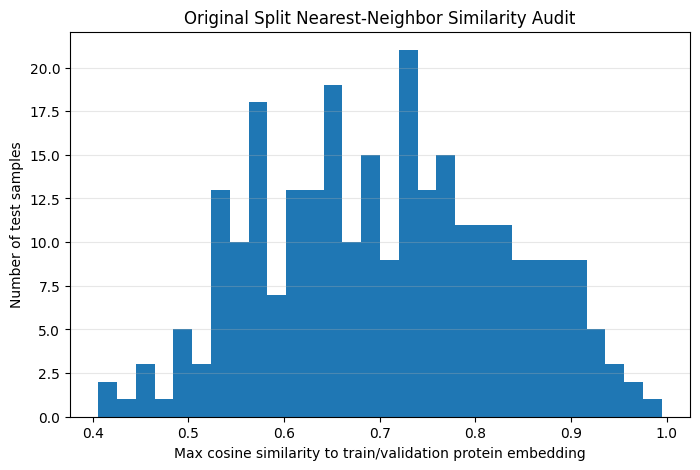

Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/figures/phase23_original_split_nearest_neighbor_similarity_histogram.png


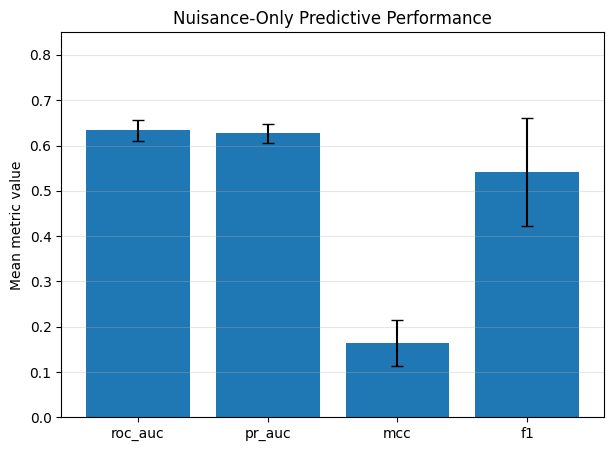

Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/figures/phase23_nuisance_only_performance.png


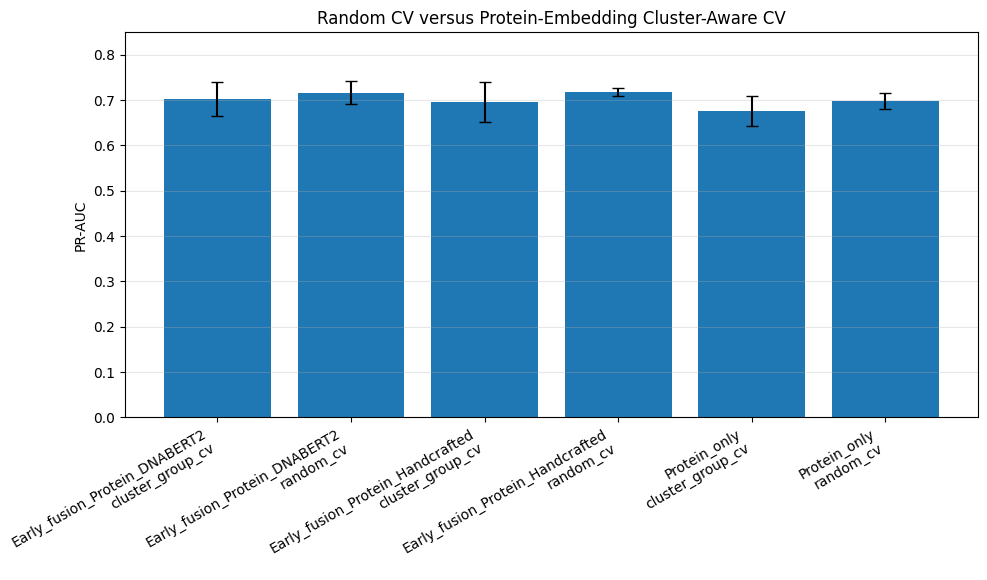

Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/figures/phase23_random_vs_cluster_group_cv_pr_auc.png


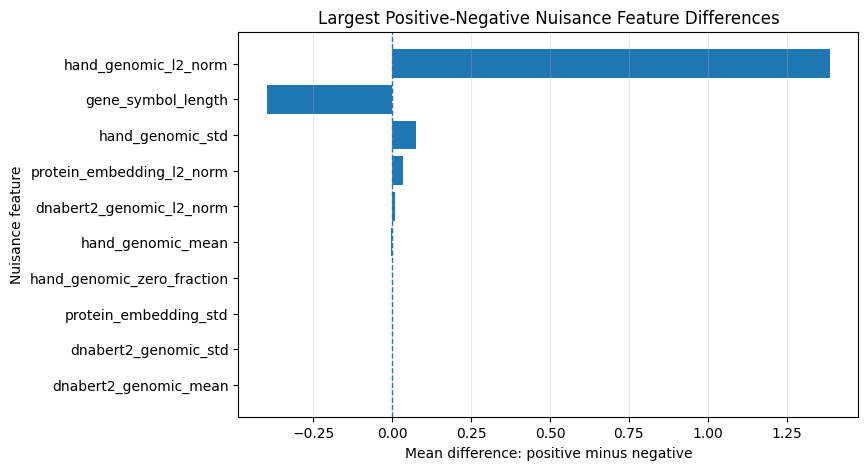

Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/figures/phase23_top_nuisance_feature_differences.png


In [11]:
# ============================================================
# FIGURES
# ============================================================

# Figure 1: nearest-neighbor similarity distribution
plt.figure(figsize=(8, 5))
plt.hist(nn_leakage_df["max_cosine_similarity_to_trainval"], bins=30)
plt.xlabel("Max cosine similarity to train/validation protein embedding")
plt.ylabel("Number of test samples")
plt.title("Original Split Nearest-Neighbor Similarity Audit")
plt.grid(axis="y", alpha=0.3)

out_path = FIGURE_DIR / "phase23_original_split_nearest_neighbor_similarity_histogram.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# Figure 2: nuisance-only performance
plt.figure(figsize=(7, 5))
plt.bar(nuisance_summary_df["metric"], nuisance_summary_df["mean"], yerr=nuisance_summary_df["sd"], capsize=4)
plt.ylabel("Mean metric value")
plt.title("Nuisance-Only Predictive Performance")
plt.ylim(0, 0.85)
plt.grid(axis="y", alpha=0.3)

out_path = FIGURE_DIR / "phase23_nuisance_only_performance.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


# Figure 3: random vs cluster group CV
if not cluster_cv_summary_df.empty:
    plot_df = cluster_cv_summary_df.copy()

    labels = []
    values = []
    errors = []

    for _, row in plot_df.iterrows():
        labels.append(row["feature_set"] + "\n" + row["cv_type"])
        values.append(row["pr_auc_mean"])
        errors.append(row["pr_auc_sd"])

    plt.figure(figsize=(11, 5))
    plt.bar(labels, values, yerr=errors, capsize=4)
    plt.ylabel("PR-AUC")
    plt.title("Random CV versus Protein-Embedding Cluster-Aware CV")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 0.85)
    plt.grid(axis="y", alpha=0.3)

    out_path = FIGURE_DIR / "phase23_random_vs_cluster_group_cv_pr_auc.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)


# Figure 4: top nuisance bias deltas
plot_bias_df = bias_test_df.copy()
plot_bias_df = plot_bias_df.dropna(subset=["delta_mean_pos_minus_neg"])
plot_bias_df["abs_delta"] = plot_bias_df["delta_mean_pos_minus_neg"].abs()
plot_bias_df = plot_bias_df.sort_values("abs_delta", ascending=True).tail(10)

plt.figure(figsize=(8, 5))
plt.barh(plot_bias_df["feature"], plot_bias_df["delta_mean_pos_minus_neg"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("Mean difference: positive minus negative")
plt.ylabel("Nuisance feature")
plt.title("Largest Positive-Negative Nuisance Feature Differences")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase23_top_nuisance_feature_differences.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [12]:
# ============================================================
# MANUSCRIPT-READY INTERPRETATION
# ============================================================

# Key values
n_very_high = int((nn_leakage_df["similarity_risk"] == "very_high_possible_duplicate").sum())
n_high = int((nn_leakage_df["similarity_risk"] == "high_near_duplicate").sum())
max_sim = float(nn_leakage_df["max_cosine_similarity_to_trainval"].max())

nuisance_pr = nuisance_summary_df[nuisance_summary_df["metric"] == "pr_auc"]["mean"].iloc[0]
nuisance_roc = nuisance_summary_df[nuisance_summary_df["metric"] == "roc_auc"]["mean"].iloc[0]

if not cluster_cv_degradation_df.empty:
    avg_pr_drop = cluster_cv_degradation_df["pr_auc_delta_group_minus_random"].mean()
    cluster_sentence = (
        f"Protein-embedding cluster-aware cross-validation produced an average PR-AUC change "
        f"of {avg_pr_drop:.3f} relative to random cross-validation across audited feature sets."
    )
else:
    cluster_sentence = (
        "Cluster-aware cross-validation was not executed in this run."
    )

methods_text = """
A leakage and bias audit was performed to evaluate whether model performance could be inflated by duplicated samples, feature-row duplication, train-test near-neighbor similarity or nuisance-variable confounding. Duplicate gene symbols and rounded duplicate feature vectors were identified across the full candidate set. For the original held-out split, each test protein embedding was compared with all train/validation embeddings using cosine similarity to identify potential near-duplicate leakage. Nuisance variables, including embedding norms, feature means, feature standard deviations, zero-vector fractions and available sequence-length proxies, were compared between positive and negative labels. A nuisance-only classifier was also evaluated to test whether simple non-biological artifacts alone could predict labels. Finally, protein-embedding clusters were used to create a group-aware split stress test as a surrogate for homology-aware evaluation.
""".strip()

results_text = f"""
The leakage audit found a maximum train/validation-to-test protein-embedding cosine similarity of {max_sim:.4f}. The number of test samples in the very-high possible-duplicate category was {n_very_high}, and the number in the high near-duplicate category was {n_high}. The nuisance-only classifier achieved PR-AUC {nuisance_pr:.3f} and ROC-AUC {nuisance_roc:.3f}, providing a direct estimate of how much label information could be recovered from simple feature-summary variables alone. {cluster_sentence}
""".strip()

discussion_text = """
The leakage and bias audit should be used as a robustness and limitation layer. If duplicate or near-duplicate samples are rare and nuisance-only performance is close to random, this supports the interpretation that the main models are not primarily driven by trivial artifacts. If cluster-aware performance drops substantially relative to random cross-validation, the results should be interpreted more cautiously because part of the signal may reflect protein-family or embedding-neighborhood similarity. In either case, reporting this audit strengthens the manuscript by explicitly addressing common reviewer concerns in disease-gene prioritization studies.
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Leakage and Bias Audit", "text": methods_text},
    {"section": "Results - Leakage and Bias Audit", "text": results_text},
    {"section": "Discussion - Robustness and Bias Interpretation", "text": discussion_text}
])

display(wording_df)

save_df(wording_df, RESULT_DIR / "phase23_manuscript_ready_wording.csv")

with open(REPORT_DIR / "phase23_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Leakage and Bias Audit,"A leakage and bias audit was performed to evaluate whether model performance could be inflated by duplicated samples, feature-row duplication, train-test near-neighbor similarity or nuisance-variable confounding. Duplicate gene symbols and rounded duplicate feature vectors were identified across the full candidate set. For the original held-out split, each test protein embedding was compared w..."
1,Results - Leakage and Bias Audit,"The leakage audit found a maximum train/validation-to-test protein-embedding cosine similarity of 0.9950. The number of test samples in the very-high possible-duplicate category was 0, and the number in the high near-duplicate category was 1. The nuisance-only classifier achieved PR-AUC 0.627 and ROC-AUC 0.633, providing a direct estimate of how much label information could be recovered from s..."
2,Discussion - Robustness and Bias Interpretation,"The leakage and bias audit should be used as a robustness and limitation layer. If duplicate or near-duplicate samples are rare and nuisance-only performance is close to random, this supports the interpretation that the main models are not primarily driven by trivial artifacts. If cluster-aware performance drops substantially relative to random cross-validation, the results should be interpret..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_manuscript_ready_wording.csv
Saved manuscript wording.


In [13]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase23_leakage_and_bias_audit_tables.xlsx"

tables = {
    "Metadata_Candidates": metadata_candidates_df,
    "Sample_Metadata": sample_metadata_df,
    "Duplicate_Summary": duplicate_summary_df,
    "Duplicate_Genes": duplicate_gene_df,
    "NN_Leakage": nn_leakage_df,
    "NN_Summary": nn_summary_df,
    "Nuisance_Features": bias_df,
    "Bias_Tests": bias_test_df,
    "Nuisance_CV": nuisance_cv_df,
    "Nuisance_Summary": nuisance_summary_df,
    "Embedding_Clusters": cluster_df,
    "Cluster_Summary": cluster_summary_df,
    "Wording": wording_df
}

if not cluster_cv_audit_df.empty:
    tables["Random_vs_Group_CV"] = cluster_cv_audit_df
    tables["Group_CV_Summary"] = cluster_cv_summary_df
    tables["Group_CV_Degradation"] = cluster_cv_degradation_df

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/excel/phase23_leakage_and_bias_audit_tables.xlsx


In [14]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 23 COMPLETE ===")

print("\nDuplicate audit summary:")
display(duplicate_summary_df)

print("\nOriginal split nearest-neighbor leakage summary:")
display(nn_summary_df)

print("\nTop nearest-neighbor risk cases:")
display(nn_leakage_df.sort_values("max_cosine_similarity_to_trainval", ascending=False).head(30))

print("\nBias tests:")
display(bias_test_df)

print("\nNuisance-only CV summary:")
display(nuisance_summary_df)

print("\nCluster summary:")
display(cluster_summary_df.sort_values('n_samples', ascending=False).head(20))

if not cluster_cv_summary_df.empty:
    print("\nRandom vs cluster-aware CV summary:")
    display(cluster_cv_summary_df)

    print("\nCluster-aware degradation:")
    display(cluster_cv_degradation_df)

print("\nWording:")
display(wording_df)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*.png")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*.csv")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*.xlsx")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

=== PHASE 23 COMPLETE ===

Duplicate audit summary:


,audit_type,n_unique_items,n_duplicated_items,n_rows_in_duplicated_items,notes
0,duplicate_gene_symbol,1806,0,0,Duplicate gene symbols across the full candidate table.
1,duplicate_feature_rows_Protein_ProtBERT,1806,0,0,Rounded feature vectors hashed at 6 decimals.
2,duplicate_feature_rows_Handcrafted_genomic,1805,1,2,Rounded feature vectors hashed at 6 decimals.
3,duplicate_feature_rows_DNABERT2_genomic,1805,1,2,Rounded feature vectors hashed at 6 decimals.
4,duplicate_feature_rows_Handcrafted_multimodal,1806,0,0,Rounded feature vectors hashed at 6 decimals.
5,duplicate_feature_rows_DNABERT2_multimodal,1806,0,0,Rounded feature vectors hashed at 6 decimals.



Original split nearest-neighbor leakage summary:


,similarity_risk,n_test_samples,mean_similarity,max_similarity
0,high_near_duplicate,1,0.994958,0.994958
1,lower_similarity,267,0.701561,0.946954
2,moderate_high_similarity,3,0.959204,0.971805



Top nearest-neighbor risk cases:


...


Cluster-aware degradation:


,feature_set,pr_auc_random,pr_auc_group,pr_auc_delta_group_minus_random,roc_auc_random,roc_auc_group,roc_auc_delta_group_minus_random,mcc_random,mcc_group,mcc_delta_group_minus_random,f1_random,f1_group,f1_delta_group_minus_random
0,Early_fusion_Protein_DNABERT2,0.71678,0.70223,-0.01455,0.72879,0.71468,-0.01412,0.32400,0.30238,-0.02163,0.60875,0.63908,0.03032
1,Early_fusion_Protein_Handcrafted,0.71774,0.69511,-0.02263,0.72577,0.70582,-0.01995,0.32713,0.28026,-0.04687,0.66058,0.62812,-0.03246
2,Protein_only,0.69860,0.67637,-0.02223,0.71315,0.69369,-0.01946,0.31110,0.28291,-0.02819,0.65525,0.68302,0.02778



Wording:


,section,text
0,Methods - Leakage and Bias Audit,"A leakage and bias audit was performed to evaluate whether model performance could be inflated by duplicated samples, feature-row duplication, train-test near-neighbor similarity or nuisance-variable confounding. Duplicate gene symbols and rounded duplicate feature vectors were identified across the full candidate set. For the original held-out split, each test protein embedding was compared w..."
1,Results - Leakage and Bias Audit,"The leakage audit found a maximum train/validation-to-test protein-embedding cosine similarity of 0.9950. The number of test samples in the very-high possible-duplicate category was 0, and the number in the high near-duplicate category was 1. The nuisance-only classifier achieved PR-AUC 0.627 and ROC-AUC 0.633, providing a direct estimate of how much label information could be recovered from s..."
2,Discussion - Robustness and Bias Interpretation,"The leakage and bias audit should be used as a robustness and limitation layer. If duplicate or near-duplicate samples are rare and nuisance-only performance is close to random, this supports the interpretation that the main models are not primarily driven by trivial artifacts. If cluster-aware performance drops substantially relative to random cross-validation, the results should be interpret..."



Figures:
/content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/figures/phase23_nuisance_only_performance.png
/content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/figures/phase23_original_split_nearest_neighbor_similarity_histogram.png
/content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/figures/phase23_random_vs_cluster_group_cv_pr_auc.png
/content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/figures/phase23_top_nuisance_feature_differences.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_cluster_group_cv_degradation_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_audit_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase23_leakage_and_bias_audit/results/phase23_duplicate_feature_rows_DNABERT2_genomic.csv
/content/drive/MyDrive/Project_Protein/model/phase23_leakage_

In [15]:
display(duplicate_summary_df)

display(nn_summary_df)

display(nn_leakage_df.sort_values(
    "max_cosine_similarity_to_trainval",
    ascending=False
).head(30))

display(bias_test_df)

display(nuisance_summary_df)

display(cluster_cv_summary_df)

display(cluster_cv_degradation_df)

,audit_type,n_unique_items,n_duplicated_items,n_rows_in_duplicated_items,notes
0,duplicate_gene_symbol,1806,0,0,Duplicate gene symbols across the full candidate table.
1,duplicate_feature_rows_Protein_ProtBERT,1806,0,0,Rounded feature vectors hashed at 6 decimals.
2,duplicate_feature_rows_Handcrafted_genomic,1805,1,2,Rounded feature vectors hashed at 6 decimals.
3,duplicate_feature_rows_DNABERT2_genomic,1805,1,2,Rounded feature vectors hashed at 6 decimals.
4,duplicate_feature_rows_Handcrafted_multimodal,1806,0,0,Rounded feature vectors hashed at 6 decimals.
5,duplicate_feature_rows_DNABERT2_multimodal,1806,0,0,Rounded feature vectors hashed at 6 decimals.


,similarity_risk,n_test_samples,mean_similarity,max_similarity
0,high_near_duplicate,1,0.994958,0.994958
1,lower_similarity,267,0.701561,0.946954
2,moderate_high_similarity,3,0.959204,0.971805


,test_sample_index,test_gene_symbol,test_label,nearest_trainval_sample_index,nearest_trainval_gene_symbol,nearest_trainval_label,nearest_trainval_split,max_cosine_similarity_to_trainval,similarity_risk
162,1697,CEP104,0,1288,SUGP2,0,val,0.994958,high_near_duplicate
124,1659,ARL15,1,587,PCNT,1,train,0.971805,moderate_high_similarity
109,1644,COLGALT1,1,560,VDR,1,train,0.955717,moderate_high_similarity
45,1580,KLHL42,0,471,MYO19,0,train,0.950091,moderate_high_similarity
257,1792,HHIPL1,1,612,SMARCAD1,0,train,0.946954,lower_similarity
21,1556,C10ORF71,0,1186,RHOG,0,train,0.936292,lower_similarity
196,1731,FFAR1,1,426,TECPR1,0,train,0.934097,lower_similarity
221,1756,SLC5A1,1,1133,HK1,0,train,0.932329,lower_similarity
89,1624,NDUFB3,0,770,CFAP47,1,train,0.921736,lower_similarity
267,1802,PIM3,1,423,IGSF10,1,train,0.921599,lower_similarity


,feature,n_pos_nonmissing,n_neg_nonmissing,median_pos,median_neg,delta_mean_pos_minus_neg,mannwhitney_p,mannwhitney_p_bh_fdr,ks_p,ks_p_bh_fdr
0,protein_embedding_l2_norm,903,903,3.457318,3.459795,0.034377,0.524922,0.758220,0.814626,1.000000
1,protein_embedding_mean,903,903,0.001392,0.001401,-0.000009,0.659585,0.766003,0.173161,0.750363
2,protein_embedding_std,903,903,0.108030,0.108104,0.001075,0.524745,0.758220,0.814626,1.000000
3,hand_genomic_l2_norm,903,903,3319.875562,3319.103217,1.387491,0.457489,0.758220,0.778449,1.000000
4,hand_genomic_mean,903,903,21.805439,21.812736,-0.003539,0.707080,0.766003,0.814626,1.000000
5,hand_genomic_std,903,903,174.587900,174.567557,0.074509,0.456069,0.758220,0.622408,1.000000
6,dnabert2_genomic_l2_norm,903,903,2.568856,2.562109,0.009617,0.218007,0.711704,0.506520,1.000000
7,dnabert2_genomic_mean,903,903,0.002705,0.002691,-0.000009,0.662463,0.766003,0.931581,1.000000
8,dnabert2_genomic_std,903,903,0.092659,0.092412,0.000347,0.218986,0.711704,0.506520,1.000000
9,protein_zero_fraction,903,903,0.000000,0.000000,-0.000001,0.317847,0.758220,1.000000,1.000000


,metric,mean,sd
0,roc_auc,0.63318,0.02407
1,pr_auc,0.62675,0.02095
2,mcc,0.16428,0.05124
3,f1,0.54146,0.11987


,feature_set,cv_type,pr_auc_mean,pr_auc_sd,roc_auc_mean,roc_auc_sd,mcc_mean,mcc_sd,f1_mean,f1_sd
0,Early_fusion_Protein_DNABERT2,cluster_group_cv,0.70223,0.03774,0.71468,0.03065,0.30238,0.04730,0.63908,0.07960
1,Early_fusion_Protein_DNABERT2,random_cv,0.71678,0.02527,0.72879,0.02309,0.32400,0.05886,0.60875,0.07970
2,Early_fusion_Protein_Handcrafted,cluster_group_cv,0.69511,0.04433,0.70582,0.03502,0.28026,0.05184,0.62812,0.06134
3,Early_fusion_Protein_Handcrafted,random_cv,0.71774,0.00824,0.72577,0.01306,0.32713,0.03912,0.66058,0.02634
4,Protein_only,cluster_group_cv,0.67637,0.03294,0.69369,0.03997,0.28291,0.04493,0.68302,0.03294
5,Protein_only,random_cv,0.69860,0.01831,0.71315,0.01716,0.31110,0.03017,0.65525,0.04439


,feature_set,pr_auc_random,pr_auc_group,pr_auc_delta_group_minus_random,roc_auc_random,roc_auc_group,roc_auc_delta_group_minus_random,mcc_random,mcc_group,mcc_delta_group_minus_random,f1_random,f1_group,f1_delta_group_minus_random
0,Early_fusion_Protein_DNABERT2,0.71678,0.70223,-0.01455,0.72879,0.71468,-0.01412,0.32400,0.30238,-0.02163,0.60875,0.63908,0.03032
1,Early_fusion_Protein_Handcrafted,0.71774,0.69511,-0.02263,0.72577,0.70582,-0.01995,0.32713,0.28026,-0.04687,0.66058,0.62812,-0.03246
2,Protein_only,0.69860,0.67637,-0.02223,0.71315,0.69369,-0.01946,0.31110,0.28291,-0.02819,0.65525,0.68302,0.02778
